In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing required modules
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

In [ ]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
# Getting the links of the images using os
filepath=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/train'):
  filepath.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/train',file_name))
filepath.sort()
train_df=pd.DataFrame(filepath,columns=["image_path"])

filepath2=[]
mask_pixel=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/train_labels'):
    filepath2.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/train_labels',file_name))
filepath2.sort()
train_df["mask_path"]=pd.DataFrame(filepath2,columns=["mask_path"])

In [ ]:
print(train_df.iloc[1,0])
print(train_df.iloc[1,1])

/content/drive/MyDrive/roads_dataset/tiff/train/10078675_15.tiff
/content/drive/MyDrive/roads_dataset/tiff/train_labels/10078675_15.tif


In [ ]:
# Validation df
filepath=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/val'):
  filepath.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/val',file_name))
filepath.sort()
val_df=pd.DataFrame(filepath,columns=["image_path"])

filepath2=[]
mask_pixel=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/val_labels'):
    filepath2.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/val_labels',file_name))
filepath2.sort()
val_df["mask_path"]=pd.DataFrame(filepath2,columns=["mask_path"])

In [ ]:
# Test df
filepath=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/test'):
  filepath.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/test',file_name))
filepath.sort()
test_df=pd.DataFrame(filepath,columns=["image_path"])

filepath2=[]
mask_pixel=[]
for file_name in os.listdir('/content/drive/MyDrive/roads_dataset/tiff/test_labels'):
    filepath2.append(os.path.join('/content/drive/MyDrive/roads_dataset/tiff/test_labels',file_name))
filepath2.sort()
test_df["mask_path"]=pd.DataFrame(filepath2,columns=["mask_path"])

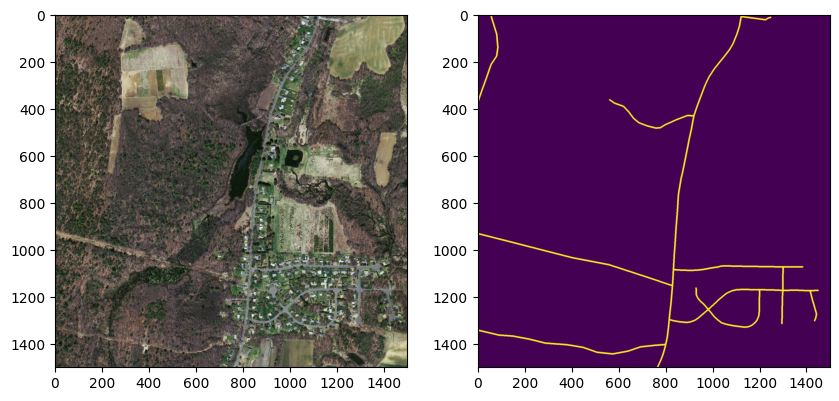

In [ ]:
# Visualization of image and it's mask
import matplotlib.pyplot as plt
from PIL import Image
img=Image.open(train_df.iloc[1,0])
mask=Image.open(train_df.iloc[1,1])
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(mask)
plt.show()

In [ ]:
## U-Net Architecture
# class of convolution which we use in horrizontal part of U-Net
class Conv2d(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.conv=nn.Conv2d(in_channels=in_c,out_channels=out_c,kernel_size=3,padding=1)
        self.relu=nn.ReLU()
        self.conv2=nn.Conv2d(in_channels=out_c,out_channels=out_c,kernel_size=3,padding=1)
    def forward(self,x):
        x=self.conv(x)
        out=self.relu(x)
        x=self.conv2(out)
        out=self.relu(x)
        return out
# Class of Up convolution which we use in decoder part
class Up_Conv2d(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.trans_conv=nn.ConvTranspose2d(in_channels=in_c,out_channels=out_c,kernel_size=2,stride=2)

    def forward(self,x):
        return self.trans_conv(x)

In [ ]:
import torch.nn.functional as F
# Main model class
class U_Net(nn.Module):
    def __init__(self,num_layers,in_c,out_c,dec_in_c,dec_out_c):
        super().__init__()
        self.down_conv=nn.ModuleList([Conv2d(in_c[i],out_c[i]) for i in range(num_layers)])
        self.up_conv=nn.ModuleList([Up_Conv2d(dec_in_c[i],dec_out_c[i]) for i in range(num_layers)])
        self.decoder_conv=nn.ModuleList([Conv2d(dec_in_c[i],dec_out_c[i]) for i in range(num_layers)])
        self.maxpool=nn.MaxPool2d(2,2)
        self.num_layers=num_layers
        self.in_c=in_c
        self.out_c=out_c
        self.bottle_neck=Conv2d(out_c[-1],out_c[-1]*2)
        self.predictions=nn.Conv2d(dec_out_c[-1],1,1)
    def forward(self,input,):
        residual_connec=[]
        # Encoder
        for i in range(self.num_layers):
            value=self.down_conv[i](input)
            residual_connec.append(value)
            next_value=self.maxpool(value)
            input=next_value

        #Bottle Neck
        input=self.bottle_neck(input)

        # Decoder
        for i in range(self.num_layers):
            value=self.up_conv[i](input)
            item=residual_connec.pop()

            # Used LLM here to solve the shape mismatch error I got
            if value.shape[2:] != item.shape[2:]:
                diff_h = item.size(2) - value.size(2)
                diff_w = item.size(3) - value.size(3)

                # Pad (left, right, top, bottom)
                value = F.pad(value, [diff_w // 2, diff_w - diff_w // 2,
                                      diff_h // 2, diff_h - diff_h // 2])

            res_con=torch.concat((value,item),dim=1) # Residual connections
            next_value=self.decoder_conv[i](res_con)
            input=next_value

        # Final pred layer
        mask_pred=self.predictions(input)

        return mask_pred

In [ ]:
## Loss
# Used LLM to find the implementation of BCE+Dice Loss for correct evaluation
class BCE_Dice_Loss(nn.Module):
    def __init__(self,bce_weight=0.5,smooth=1e-6):
        super().__init__()
        self.bce_weight=bce_weight
        self.smooth=smooth
        self.bce=nn.BCEWithLogitsLoss()

    def forward(self,logits,masks):
        bce_loss = self.bce(logits, masks)
        probs = torch.sigmoid(logits)

        probs_flat = probs.view(-1)
        targets_flat = masks.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_coeff = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1 - dice_coeff

        combined_loss = (self.bce_weight * bce_loss) + ((1 - self.bce_weight) * dice_loss)

        return combined_loss

In [ ]:
# Initialization of all the arguments, model , criterion and optimizer
num_layers=4
in_channels=[3,64,128,256]
out_channels=[64,128,256,512]
decoder_in_channels=[1024,512,256,128]
decoder_out_channels=[512,256,128,64]

model1=U_Net(num_layers,in_channels,out_channels,decoder_in_channels,decoder_out_channels).to(device)
criterion=BCE_Dice_Loss().to(device)
optimizer=torch.optim.Adam(model1.parameters(),lr=0.0001)

In [ ]:
## Training Loop
model1.train()
for epoch in range(5):
    total_loss=0
    for i in range(130):
      # Passing only one image per loop for memory management
      # I also decresead the number of images since it took a lot of time even on GPU to complete an epoch
        img=Image.open(train_df.iloc[i,0]).convert("RGB")
        mask=Image.open(train_df.iloc[i,1]).convert("L")
        X_batch=torch.from_numpy(np.array(img)).unsqueeze(0)
        y_batch=torch.from_numpy(np.array(mask)).unsqueeze(0)
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)
        X_batch=X_batch.float()/255.0
        y_batch=y_batch.float()/255.0
        optimizer.zero_grad()
        predictions=model1(X_batch.permute(0,3,1,2))
        loss=criterion(predictions,y_batch.unsqueeze(1).float())
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        del X_batch , y_batch
    print(f"Epoch {epoch+1} loss : {total_loss}")

Epoch 1 loss : 84.11785227060318
Epoch 2 loss : 72.0891541838646
Epoch 3 loss : 61.69602647423744
Epoch 4 loss : 54.547320798039436
Epoch 5 loss : 52.747755497694016


In [ ]:
## Seeing how the look like
print(predictions)
mask=Image.open(train_df.iloc[129,1]).convert("L")
print(np.array(mask))

tensor([[[[-1.2171, -2.2216, -2.7097,  ..., -3.2890, -2.7375, -1.6741],
          [-2.0302, -3.6327, -4.4416,  ..., -5.1723, -4.3770, -2.6490],
          [-2.3461, -4.2385, -5.2379,  ..., -5.7400, -4.8023, -2.9778],
          ...,
          [-1.0832, -1.7161, -1.5875,  ..., -4.9786, -4.1055, -2.4591],
          [-1.0277, -1.7630, -1.8845,  ..., -4.1414, -3.4303, -2.0911],
          [-0.6048, -1.1148, -1.2671,  ..., -2.4989, -2.0899, -1.2847]]]],
       device='cuda:0', grad_fn=<ConvolutionBackward0>)
[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [255   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


In [ ]:
model1.eval()
correct_id=0
total_id=0
with torch.no_grad():
  for i in range(len(test_df)):
    img=Image.open(test_df.iloc[i,0]).convert("RGB")
    mask=Image.open(test_df.iloc[i,1]).convert("L")
    X_batch=torch.from_numpy(np.array(img)).unsqueeze(0)
    y_batch=torch.from_numpy(np.array(mask)).unsqueeze(0)
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)

    X_batch=X_batch.float()/255.0
    y_batch=y_batch.float()/255.0

    predictions=model1(X_batch.permute(0,3,1,2))

    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

    predictions=predictions.view(-1)
    y_batch=y_batch.view(-1)

    # for k in range(len(predictions)):
    #   total_id+=1
    #   if(predictions[k]==y_batch[k]):
    #     correct_id+=1
    correct_id+=(predictions==y_batch).sum().item()
    total_id+=y_batch.numel()
  print(f"Accuracy = {correct_id*100/total_id}%")

Accuracy = 93.30304308390022%


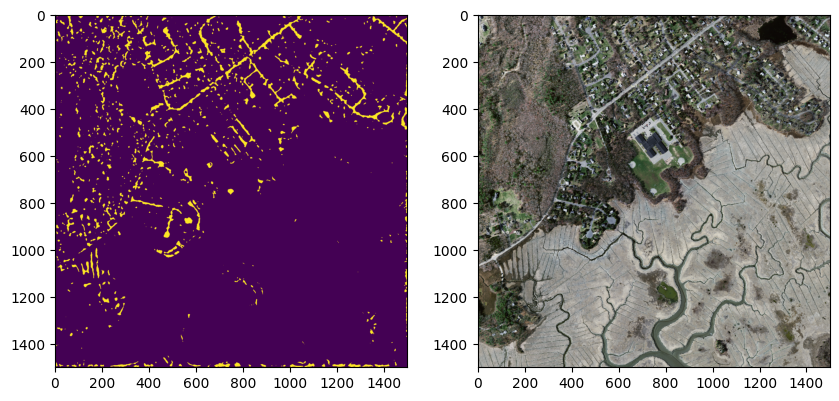

In [ ]:
# Visualization of real image and masked roads
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(predictions.view(1500,1500).cpu())
plt.subplot(1,2,2)
img=Image.open(test_df.iloc[-1,0])
plt.imshow(img)
plt.show()

In [ ]:
# Attention U-Net Architecture
# Attention class which will be added in skip connections instead of directly concatenating the encoder parts
class Attention_gate(nn.Module):
  def __init__(self,in_c,out_c):
    super().__init__()
    self.g_conv=nn.Conv2d(out_c,out_c,1)
    self.x_conv=nn.Conv2d(in_c,out_c,3,2)
    self.phi_conv=nn.Conv2d(out_c,1,1)
    self.relu=nn.ReLU()
    self.sig=nn.Sigmoid()
    self.up_conv=nn.ConvTranspose2d(1,1,2,2)
  def forward(self,x,g):
    x_sc=self.x_conv(x)
    g=self.g_conv(g)

    if x_sc.shape[2:]!=g.shape[2:]:
      x_sc=F.pad(x_sc,(1,0,1,0))

    att_scores=torch.add(x_sc,g)
    att_scores=self.relu(att_scores)
    phi_out=self.phi_conv(att_scores)
    att_weights=self.sig(phi_out)
    weights_up=self.up_conv(att_weights)

    if x.shape[2:] != weights_up.shape[2:]:
      weights_up=F.pad(weights_up,(1,0,1,0))

    sim_scores=torch.mul(weights_up,x)

    return sim_scores

In [ ]:
# Main Attention U-Net class
class Attention_U_Net(nn.Module):
    def __init__(self,num_layers,in_c,out_c,dec_in_c,dec_out_c):
        super().__init__()
        self.down_conv=nn.ModuleList([Conv2d(in_c[i],out_c[i]) for i in range(num_layers)])
        self.up_conv=nn.ModuleList([Up_Conv2d(dec_in_c[i],dec_out_c[i]) for i in range(num_layers)])
        self.decoder_conv=nn.ModuleList([Conv2d(dec_in_c[i],dec_out_c[i]) for i in range(num_layers)])
        self.maxpool=nn.MaxPool2d(2,2)
        self.num_layers=num_layers
        self.in_c=in_c
        self.out_c=out_c
        self.bottle_neck=Conv2d(out_c[-1],out_c[-1]*2)
        self.predictions=nn.Conv2d(dec_out_c[-1],1,1)
        self.atten_gate=nn.ModuleList([Attention_gate(dec_out_c[i],dec_in_c[i]) for i in range(num_layers)])
    def forward(self,input):
        residual_connec=[]
        # Encoder
        for i in range(self.num_layers):
            value=self.down_conv[i](input)
            residual_connec.append(value)
            next_value=self.maxpool(value)
            input=next_value

        #Bottle Neck
        input=self.bottle_neck(input)

        # Decoder
        for i in range(self.num_layers):
            value=self.up_conv[i](input)
            item=residual_connec.pop()
            # Padding to fit the correct shape
            if value.shape[2:] != item.shape[2:]:
                diff_h = item.size(2) - value.size(2)
                diff_w = item.size(3) - value.size(3)

                # Pad (left, right, top, bottom)
                value = F.pad(value, [diff_w // 2, diff_w - diff_w // 2,
                                      diff_h // 2, diff_h - diff_h // 2])

            #Attention part
            sim_scores=self.atten_gate[i](item,input)

            res_con=torch.concat((value,sim_scores),dim=1)
            next_value=self.decoder_conv[i](res_con)
            input=next_value

        # Final pred layer
        mask_pred=self.predictions(input)

        return mask_pred

In [ ]:
# Initialization of all the arguments , model , criterion and optimizer
num_layers=4
in_channels=[3,64,128,256]
out_channels=[64,128,256,512]
decoder_in_channels=[1024,512,256,128]
decoder_out_channels=[512,256,128,64]

model2=Attention_U_Net(num_layers,in_channels,out_channels,decoder_in_channels,decoder_out_channels).to(device)
criterion=BCE_Dice_Loss().to(device)
optimizer=torch.optim.Adam(model2.parameters(),lr=0.0001)

In [ ]:
# Training Loop
training_loss=[]
validation_loss=[]
for epoch in range(5):
    total_loss=0
    val_loss=0
    model2.train()
    for i in range(130):
        img=Image.open(train_df.iloc[i,0]).convert("RGB")
        mask=Image.open(train_df.iloc[i,1]).convert("L")
        X_batch=torch.from_numpy(np.array(img)).unsqueeze(0)
        y_batch=torch.from_numpy(np.array(mask)).unsqueeze(0)
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)
        X_batch=X_batch.float()/255.0
        y_batch=y_batch.float()/255.0
        optimizer.zero_grad()
        predictions=model2(X_batch.permute(0,3,1,2))
        loss=criterion(predictions,y_batch.unsqueeze(1).float())
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        del X_batch , y_batch

    model2.eval()
    with torch.no_grad():
      for i in range(7):
        img=Image.open(val_df.iloc[i,0]).convert("RGB")
        mask=Image.open(val_df.iloc[i,1]).convert("L")
        X_batch=torch.from_numpy(np.array(img)).unsqueeze(0)
        y_batch=torch.from_numpy(np.array(mask)).unsqueeze(0)
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)
        X_batch=X_batch.float()/255.0
        y_batch=y_batch.float()/255.0
        predictions=model2(X_batch.permute(0,3,1,2))
        loss=criterion(predictions,y_batch.unsqueeze(1).float())
        val_loss+=loss.item()
        del X_batch , y_batch
    print(f"Epoch {epoch+1} loss : {total_loss}")
    print(f"Validation Epoch {epoch+1} loss :{val_loss}")
    training_loss.append(total_loss/130)
    validation_loss.append(val_loss/7)

Epoch 1 loss : 71.81805557012558
Validation Epoch 1 loss :3.7534605264663696
Epoch 2 loss : 65.0731740295887
Validation Epoch 2 loss :3.2221415042877197
Epoch 3 loss : 56.43783012032509
Validation Epoch 3 loss :3.401509016752243
Epoch 4 loss : 54.75484022498131
Validation Epoch 4 loss :3.0508108139038086
Epoch 5 loss : 53.7769722789526
Validation Epoch 5 loss :3.014329642057419


In [ ]:
model2.eval()
correct_id=0
total_id=0
with torch.no_grad():
  for i in range(len(test_df)):
    img=Image.open(test_df.iloc[i,0]).convert("RGB")
    mask=Image.open(test_df.iloc[i,1]).convert("L")
    X_batch=torch.from_numpy(np.array(img)).unsqueeze(0)
    y_batch=torch.from_numpy(np.array(mask)).unsqueeze(0)
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)

    X_batch=X_batch.float()/255.0
    y_batch=y_batch.float()/255.0

    predictions=model2(X_batch.permute(0,3,1,2))

    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

    predictions=predictions.view(-1)
    y_batch=y_batch.view(-1)

    correct_id+=(predictions==y_batch).sum().item()
    total_id+=y_batch.numel()
  print(f"Accuracy = {correct_id*100/total_id}%")

Accuracy = 93.64958911564626%


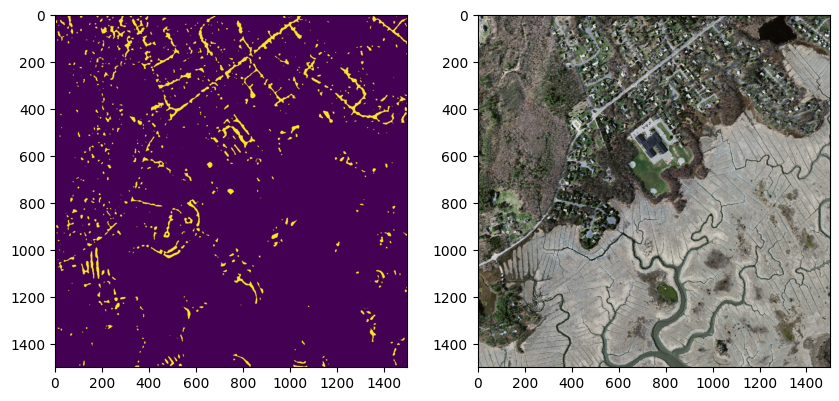

In [ ]:
# Visualizing the masks and real image
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(predictions.view(1500,1500).cpu())
plt.subplot(1,2,2)
img=Image.open(test_df.iloc[-1,0])
plt.imshow(img)
plt.show()

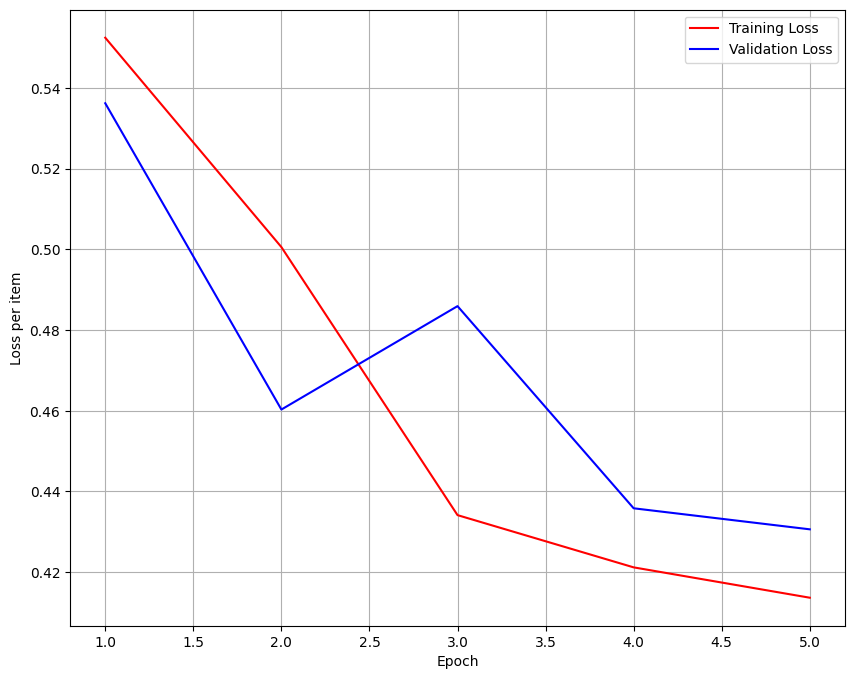

In [ ]:
# Visualizing the train and val loss plots
plt.figure(figsize=(10,8))
plt.plot([i+1 for i in range(5)],training_loss,color="red",label="Training Loss")
plt.plot([i+1 for i in range(5)],validation_loss,color="blue",label="Validation Loss")
plt.grid(True)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss per item")
plt.show()